# Análise dos Microdados do SISVAN em Recife (2023)
## Pipeline de preparação, clusterização de unidades de saúde e inferência estatística

Este notebook apresenta um fluxo reprodutível para filtrar os microdados do SISVAN referentes ao município do Recife, tratar inconsistências, construir um escore nutricional, agregar indicadores por unidade de saúde e identificar perfis assistenciais por meio de clusterização com K-Means. Ao final, são aplicados testes de hipótese para comparar os grupos identificados e discutir sua interpretação estatística.

## 1. Contextualização do Problema e dos Dados

O Sistema de Vigilância Alimentar e Nutricional (SISVAN) é a estratégia do Sistema Único de Saúde (SUS) voltada ao monitoramento contínuo do estado nutricional e do consumo alimentar da população acompanhada na atenção primária. Na prática, os dados são registrados nas unidades de saúde durante atendimentos, ações de acompanhamento e avaliações antropométricas, sendo posteriormente consolidados em bases administrativas que permitem análises em escala municipal, estadual e nacional.

Nos serviços da rede pública, profissionais das Unidades Básicas de Saúde coletam informações como idade, sexo, peso, altura e classificação nutricional segundo a fase da vida. Esses registros são fundamentais para subsidiar o planejamento de ações de promoção da saúde, prevenção de agravos nutricionais e organização do cuidado em territórios socialmente heterogêneos.

Neste estudo, utilizam-se os microdados do SISVAN de 2023 para o município do Recife. O objetivo é construir um pipeline analítico que permita: (i) filtrar e tratar os registros do município, (ii) sintetizar o perfil nutricional dos atendimentos em um escore padronizado, (iii) agregar essas informações por unidade de saúde e (iv) identificar padrões latentes entre unidades por meio de clusterização não supervisionada, com posterior comparação estatística entre os grupos formados.

## 2. Objetivos Analíticos e Estratégia Metodológica

A análise foi organizada para responder a uma questão central: **há perfis distintos de unidades de saúde no Recife quando se considera o conjunto de atendimentos nutricionais registrados no SISVAN em 2023?**

Para responder a essa pergunta, o notebook foi estruturado em cinco etapas principais:

1. **Extração dos microdados do Recife** a partir da base nacional do SISVAN.
2. **Limpeza e padronização** das variáveis antropométricas, com remoção de registros inconsistentes.
3. **Construção de um escore nutricional sintético**, respeitando as classificações específicas de cada fase da vida.
4. **Agregação por unidade de saúde** e aplicação de **clusterização não supervisionada com K-Means** para identificar perfis semelhantes entre estabelecimentos.
5. **Comparação estatística entre os grupos formados**, com uso de testes de hipótese e comparação múltipla entre clusters elegíveis.

A lógica do notebook, portanto, não é a de uma auditoria do código, mas a de uma narrativa analítica: cada seção documenta uma decisão metodológica necessária para transformar os microdados brutos em resultados interpretáveis do ponto de vista estatístico e de saúde pública.

## 3. Configurações Iniciais

Nesta etapa, são centralizados os imports, definidos os caminhos dos arquivos e realizada uma inspeção preliminar da base nacional para verificar a estrutura das variáveis disponíveis.

In [94]:
import warnings
from itertools import combinations
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import pyarrow as pa
import pyarrow.parquet as pq
import scipy.stats as stats
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:.2f}".format
sns.set_theme(style="whitegrid")
SEMENTE_ALEATORIA = 42
PALETA_CLUSTERS = {
    0: "#4C72B0",
    1: "#DD8452",
    2: "#55A868",
    3: "#C44E52",
}
PALETA_CLUSTERS_PLOTLY = {
    "Cluster 0": "#4C72B0",
    "Cluster 1": "#DD8452",
    "Cluster 2": "#55A868",
    "Cluster 3": "#C44E52",
}

In [95]:
CAMINHO_CSV = "/Users/lucasreis/Downloads/sisvan_estado_nutricional_2023.csv"
CAMINHO_PARQUET = Path("data/sisvan_recife.parquet")

amostra_inicial = pd.read_csv(
    CAMINHO_CSV,
    encoding="latin1",
    sep=";",
    nrows=5_000,
)

amostra_inicial.head()

,CO_ACOMPANHAMENTO,CO_PESSOA_SISVAN,ST_PARTICIPA_ANDI,CO_MUNICIPIO_IBGE,SG_UF,NO_MUNICIPIO,CO_CNES,NU_IDADE_ANO,NU_FASE_VIDA,DS_FASE_VIDA,...,PESO X ALTURA,CRI. ALTURA X IDADE,CRI. IMC X IDADE,ADO. ALTURA X IDADE,ADO. IMC X IDADE,CO_ESTADO_NUTRI_ADULTO,CO_ESTADO_NUTRI_IDOSO,CO_ESTADO_NUTRI_IMC_SEMGEST,CO_SISTEMA_ORIGEM_ACOMP,SISTEMA_ORIGEM_ACOMP
0,CC55ACC0A28DAD8572BC5B0C92F0422CCD6DA117,71B6507068CE0032C046597636AD2A97A9DB2296,NaN,430950,RS,GUARANI DAS MISSOES,2259036,37,7.00,ADULTO,...,NaN,NaN,NaN,NaN,NaN,Baixo peso,NaN,NaN,4,E-SUS AB
1,09B9CFF04C84B907CAC8E44A6E1FF16FDA3D3CE1,879DFEE616CDC4E1AA2703DB16280CAC5C44A8B1,NaN,410530,PR,CEU AZUL,2572109,84,8.00,IDOSO,...,NaN,NaN,NaN,NaN,NaN,NaN,Sobrepeso,NaN,4,E-SUS AB
2,A936D6ED2C263A0E3475C874AECC37B3CBB3ACBF,9687B8BBAEA55EA363AC48DFD80ED67D613E69A7,NaN,240810,RN,NATAL,2408740,21,7.00,ADULTO,...,NaN,NaN,NaN,NaN,NaN,Obesidade Grau III,NaN,NaN,4,E-SUS AB
3,1993B710C5F896A6C6570C5C83070CC0667050EE,135B0B484BCEEB79EFE95AC232674FDA21659EC6,NaN,221100,PI,TERESINA,5286239,37,7.00,ADULTO,...,NaN,NaN,NaN,NaN,NaN,Sobrepeso,NaN,NaN,4,E-SUS AB
4,88B4926D55BC4AF61FFA8BD4E42BEA4FDD6496F4,16A509A9782CA11C320AECCC99F57D52E906CAE0,NaN,355030,SP,SAO PAULO,6564410,61,8.00,IDOSO,...,NaN,NaN,NaN,NaN,NaN,NaN,Adequado ou eutrófico,NaN,4,E-SUS AB


## 4. Extração dos Microdados de Recife

A base nacional é percorrida em blocos para reduzir o consumo de memória. Em seguida, mantêm-se apenas os registros do município do Recife e os dados filtrados são persistidos em formato Parquet para agilizar as etapas seguintes do pipeline.

In [96]:
CAMINHO_PARQUET.parent.mkdir(parents=True, exist_ok=True)

if CAMINHO_PARQUET.exists():
    print(f"Arquivo Parquet já disponível em: {CAMINHO_PARQUET}")
else:
    tamanho_bloco = 200_000
    gravador_parquet = None
    total_linhas_lidas = 0
    total_linhas_filtradas = 0

    for bloco in pd.read_csv(
        CAMINHO_CSV,
        encoding="latin1",
        sep=";",
        chunksize=tamanho_bloco,
    ):
        total_linhas_lidas += len(bloco)
        bloco_recife = bloco.loc[
            bloco["NO_MUNICIPIO"].astype("string").str.strip() == "RECIFE"
        ].copy()

        if bloco_recife.empty:
            continue

        total_linhas_filtradas += len(bloco_recife)
        tabela_recife = pa.Table.from_pandas(bloco_recife, preserve_index=False)

        if gravador_parquet is None:
            gravador_parquet = pq.ParquetWriter(CAMINHO_PARQUET, tabela_recife.schema)

        gravador_parquet.write_table(tabela_recife)

    if gravador_parquet is not None:
        gravador_parquet.close()

    print(f"Linhas lidas: {total_linhas_lidas:,}")
    print(f"Linhas filtradas para Recife: {total_linhas_filtradas:,}")
    print(f"Arquivo salvo em: {CAMINHO_PARQUET}")

Arquivo Parquet já disponível em: data/sisvan_recife.parquet


## 5. Carregamento e Limpeza dos Dados

Após a extração, os registros do Recife são carregados do arquivo Parquet e submetidos à padronização dos campos antropométricos. Nesta etapa, pesos, alturas e idades inválidas são removidos para reduzir ruído antes da engenharia de atributos.

In [97]:
df_sisvan_recife = pd.read_parquet(CAMINHO_PARQUET)
df_limpo = df_sisvan_recife.copy()

df_limpo["NU_PESO"] = pd.to_numeric(
    df_limpo["NU_PESO"].astype("string").str.replace(",", ".", regex=False),
    errors="coerce",
)
df_limpo["NU_ALTURA"] = pd.to_numeric(
    df_limpo["NU_ALTURA"].astype("string").str.replace(",", ".", regex=False),
    errors="coerce",
) / 100

df_limpo = df_limpo.dropna(subset=["NU_PESO", "NU_ALTURA", "NU_IDADE_ANO"]).copy()

definir_peso_valido = df_limpo["NU_PESO"].between(2.0, 300.0)
definir_altura_valida = df_limpo["NU_ALTURA"].between(0.40, 2.50)
definir_idade_valida = df_limpo["NU_IDADE_ANO"].between(0, 120)

df_limpo = df_limpo.loc[
    definir_peso_valido & definir_altura_valida & definir_idade_valida
].drop_duplicates().copy()

print(f"Linhas originais em Recife: {len(df_sisvan_recife)}")
print(f"Linhas após limpeza: {len(df_limpo)}")
print(f"Registros descartados: {len(df_sisvan_recife) - len(df_limpo)}")

df_limpo[["CO_CNES", "NU_IDADE_ANO", "NU_PESO", "NU_ALTURA", "DS_FASE_VIDA"]].head()

Linhas originais em Recife: 116700
Linhas após limpeza: 116688
Registros descartados: 12


,CO_CNES,NU_IDADE_ANO,NU_PESO,NU_ALTURA,DS_FASE_VIDA
0,3470261.00,9,43.00,1.35,ENTRE 7 ANOS A 10 ANOS
1,817.00,7,18.00,1.33,ENTRE 7 ANOS A 10 ANOS
2,3562581.00,27,67.00,1.73,ADULTO
3,2752824.00,10,35.00,1.25,ADOLESCENTE
4,1236.00,22,85.00,1.55,ADULTO


## 6. Engenharia de Atributos

O escore nutricional continua sendo construído de forma vetorizada, respeitando as classificações específicas de cada fase da vida. Nesta versão, a engenharia de atributos também passa a incorporar variáveis adicionais para enriquecer a clusterização por unidade de saúde, incluindo composição racial declarada, estrutura etária do público atendido, origem do acompanhamento e IMC médio.

Como contrapartida, variáveis com baixa qualidade informacional — como povo/comunidade e escolaridade — são mantidas apenas como diagnóstico de cobertura e não entram no modelo de clusterização, evitando ruído excessivo e interpretações frágeis.

In [98]:
df_engenharia = df_limpo.copy()

df_engenharia["imc_calculado"] = df_engenharia["NU_PESO"] / (df_engenharia["NU_ALTURA"] ** 2)

mapa_infantil_adolescente = {
    "Magreza acentuada": 0,
    "Magreza": 2,
    "Eutrofia": 10,
    "Sobrepeso": 5,
    "Obesidade": 0,
    "Grave obesidade": 0,
}
mapa_adulto = {
    "Baixo peso": 2,
    "Adequado ou eutrófico": 10,
    "Eutrofia": 10,
    "Sobrepeso": 5,
    "Obesidade Grau I": 0,
    "Obesidade Grau II": 0,
    "Obesidade Grau III": 0,
}
mapa_idoso = {
    "Baixo peso": 2,
    "Adequado ou eutrófico": 10,
    "Sobrepeso": 5,
}

coluna_status_nutricional = np.select(
    [
        df_engenharia["NU_FASE_VIDA"].between(1, 5),
        df_engenharia["NU_FASE_VIDA"] == 6,
        df_engenharia["NU_FASE_VIDA"] == 7,
        df_engenharia["NU_FASE_VIDA"] == 8,
    ],
    [
        df_engenharia["CRI. IMC X IDADE"].to_numpy(),
        df_engenharia["ADO. IMC X IDADE"].to_numpy(),
        df_engenharia["CO_ESTADO_NUTRI_ADULTO"].to_numpy(),
        df_engenharia["CO_ESTADO_NUTRI_IDOSO"].to_numpy(),
    ],
    default=np.nan,
)

df_engenharia["status_nutricional"] = pd.Series(
    coluna_status_nutricional,
    index=df_engenharia.index,
    dtype="object",
)

escore_especifico = pd.Series(np.nan, index=df_engenharia.index, dtype="float64")
mascara_infancia = df_engenharia["NU_FASE_VIDA"].between(1, 5)
mascara_adolescencia = df_engenharia["NU_FASE_VIDA"] == 6
mascara_adulto = df_engenharia["NU_FASE_VIDA"] == 7
mascara_idoso = df_engenharia["NU_FASE_VIDA"] == 8

escore_especifico.loc[mascara_infancia | mascara_adolescencia] = df_engenharia.loc[
    mascara_infancia | mascara_adolescencia,
    "status_nutricional",
].map(mapa_infantil_adolescente)
escore_especifico.loc[mascara_adulto] = df_engenharia.loc[
    mascara_adulto,
    "status_nutricional",
].map(mapa_adulto)
escore_especifico.loc[mascara_idoso] = df_engenharia.loc[
    mascara_idoso,
    "status_nutricional",
].map(mapa_idoso)

status_geral = df_engenharia["DS_IMC"].astype("string").str.upper().fillna("")
escore_geral = pd.Series(
    np.select(
        [
            status_geral.str.contains("EUTROFIA|ADEQUADO", regex=True),
            status_geral.str.contains("SOBREPESO|PRÉ-OBESIDADE|PRE-OBESIDADE", regex=True),
            status_geral.ne(""),
        ],
        [10, 5, 0],
        default=np.nan,
    ),
    index=df_engenharia.index,
    dtype="float64",
)

df_engenharia["escore_saudavel"] = escore_especifico.fillna(escore_geral)
df_engenharia = df_engenharia.dropna(subset=["escore_saudavel"]).copy()

df_engenharia["indicador_crianca"] = df_engenharia["NU_FASE_VIDA"].between(1, 5).astype(int)
df_engenharia["indicador_idoso"] = (df_engenharia["NU_FASE_VIDA"] == 8).astype(int)
df_engenharia["indicador_auxilio_brasil"] = (
    df_engenharia["SISTEMA_ORIGEM_ACOMP"].astype("string").str.upper().str.strip()
    == "AUXILIO BRASIL"
).astype(int)

df_engenharia["raca_declarada"] = (
    df_engenharia["DS_RACA_COR"].astype("string").str.upper().str.strip()
)
racas_validas = {"BRANCA", "PRETA", "PARDA", "INDIGENA"}
df_engenharia["raca_valida"] = df_engenharia["raca_declarada"].isin(racas_validas)
df_engenharia["indicador_branca"] = np.where(
    df_engenharia["raca_valida"],
    (df_engenharia["raca_declarada"] == "BRANCA").astype(float),
    np.nan,
)
df_engenharia["indicador_parda"] = np.where(
    df_engenharia["raca_valida"],
    (df_engenharia["raca_declarada"] == "PARDA").astype(float),
    np.nan,
)
df_engenharia["indicador_preta"] = np.where(
    df_engenharia["raca_valida"],
    (df_engenharia["raca_declarada"] == "PRETA").astype(float),
    np.nan,
)

df_engenharia["escolaridade_informada"] = (
    df_engenharia["DS_ESCOLARIDADE"].astype("string").str.upper().str.strip()
    .ne("SEM INFORMAÇÃO")
    & df_engenharia["DS_ESCOLARIDADE"].notna()
)
df_engenharia["povo_comunidade_informado"] = (
    df_engenharia["DS_POVO_COMUNIDADE"].astype("string").str.upper().str.strip()
    .ne("NÃO INFORMADO")
    & df_engenharia["DS_POVO_COMUNIDADE"].notna()
)

resumo_fase_vida = (
    df_engenharia.groupby("DS_FASE_VIDA", dropna=False)
    .agg(
        total_registros=("CO_PESSOA_SISVAN", "count"),
        escore_medio=("escore_saudavel", "mean"),
        imc_medio=("imc_calculado", "mean"),
    )
    .sort_values("total_registros", ascending=False)
)

cobertura_variaveis = pd.DataFrame(
    {
        "cobertura_raca_valida": [df_engenharia["raca_valida"].mean()],
        "cobertura_escolaridade_informada": [df_engenharia["escolaridade_informada"].mean()],
        "cobertura_povo_comunidade": [df_engenharia["povo_comunidade_informado"].mean()],
    }
).round(4)

print(f"Registros prontos para modelagem: {len(df_engenharia)}")
print("\nCobertura das variáveis adicionais:")
print(cobertura_variaveis.T)
resumo_fase_vida.head(10)

Registros prontos para modelagem: 116688

Cobertura das variáveis adicionais:
                                    0
cobertura_raca_valida            0.49
cobertura_escolaridade_informada 0.03
cobertura_povo_comunidade        0.00


,total_registros,escore_medio,imc_medio
DS_FASE_VIDA,,,
ADULTO,50630,3.89,29.63
IDOSO,17995,6.21,28.35
ADOLESCENTE,12791,6.47,22.17
ENTRE 6 MESES A 2 ANOS,10906,6.47,17.69
ENTRE 2 ANOS A 5 ANOS,8363,6.14,16.92
ENTRE 5 ANOS A 7 ANOS,5769,6.05,17.26
ENTRE 7 ANOS A 10 ANOS,5663,6.08,18.25
MENOR DE 6 MESES,4571,6.87,16.97


## 7. Modelagem Não Supervisionada

A unidade de análise continua sendo a unidade de saúde (`CO_CNES`), mas agora os registros individuais são agregados para sintetizar um perfil mais rico de cada estabelecimento. Além do escore nutricional médio, passam a entrar na clusterização variáveis de composição por sexo, estrutura etária, composição racial declarada, participação de atendimentos vinculados ao Auxílio Brasil e IMC médio.

As variáveis de escolaridade e povo/comunidade permanecem apenas como diagnóstico de cobertura e são excluídas do modelo por apresentarem baixa qualidade informacional. Já as proporções raciais são calculadas apenas entre registros com raça declarada válida, reduzindo o efeito de categorias pouco informativas como `SEM INFORMACAO`.

In [99]:
df_preparacao = df_engenharia.copy()
df_preparacao["indicador_mulher"] = (df_preparacao["SG_SEXO"] == "F").astype(int)

df_unidades_saude = (
    df_preparacao.groupby("CO_CNES")
    .agg(
        total_atendimentos=("CO_PESSOA_SISVAN", "count"),
        media_escore_saudavel=("escore_saudavel", "mean"),
        media_idade=("NU_IDADE_ANO", "mean"),
        media_imc=("imc_calculado", "mean"),
        proporcao_mulheres=("indicador_mulher", "mean"),
        proporcao_crianca=("indicador_crianca", "mean"),
        proporcao_idoso=("indicador_idoso", "mean"),
        proporcao_branca=("indicador_branca", "mean"),
        proporcao_parda=("indicador_parda", "mean"),
        proporcao_preta=("indicador_preta", "mean"),
        proporcao_auxilio_brasil=("indicador_auxilio_brasil", "mean"),
        proporcao_raca_valida=("raca_valida", "mean"),
        cobertura_escolaridade=("escolaridade_informada", "mean"),
        cobertura_povo_comunidade=("povo_comunidade_informado", "mean"),
    )
    .reset_index()
)

TAMANHO_MINIMO_AMOSTRA = 30
df_unidades_saude = df_unidades_saude.loc[
    df_unidades_saude["total_atendimentos"] >= TAMANHO_MINIMO_AMOSTRA
].copy()

colunas_modelagem = [
    "media_escore_saudavel",
    "media_imc",
    "proporcao_mulheres",
    "proporcao_crianca",
    "proporcao_idoso",
    "proporcao_branca",
    "proporcao_parda",
    "proporcao_preta",
    "proporcao_auxilio_brasil",
]

correlacao_variaveis = df_unidades_saude[colunas_modelagem].corr().round(2)

escalador = StandardScaler()
matriz_padronizada = escalador.fit_transform(df_unidades_saude[colunas_modelagem])

df_modelo_escalado = pd.DataFrame(
    matriz_padronizada,
    columns=colunas_modelagem,
    index=df_unidades_saude.index,
)
df_modelo_escalado["CO_CNES"] = df_unidades_saude["CO_CNES"].to_numpy()

print(f"Unidades elegíveis para o K-Means: {len(df_unidades_saude)}")
print("\nMatriz de correlação das variáveis de clusterização:")
print(correlacao_variaveis)
print("\nResumo das variáveis agregadas usadas no modelo:")
display(df_unidades_saude[colunas_modelagem].describe().T)

df_unidades_saude.head()

Unidades elegíveis para o K-Means: 176

Matriz de correlação das variáveis de clusterização:
                          media_escore_saudavel  media_imc  \
media_escore_saudavel                      1.00      -0.64   
media_imc                                 -0.64       1.00   
proporcao_mulheres                        -0.51       0.53   
proporcao_crianca                          0.32      -0.90   
proporcao_idoso                           -0.17       0.69   
proporcao_branca                           0.08       0.09   
proporcao_parda                           -0.06      -0.16   
proporcao_preta                           -0.03       0.10   
proporcao_auxilio_brasil                   0.12      -0.49   

                          proporcao_mulheres  proporcao_crianca  \
media_escore_saudavel                  -0.51               0.32   
media_imc                               0.53              -0.90   
proporcao_mulheres                      1.00              -0.42   
proporcao_crianca 

,count,mean,std,min,25%,50%,75%,max
media_escore_saudavel,176.00,5.21,0.60,2.81,4.96,5.24,5.47,8.45
media_imc,176.00,24.95,2.24,17.12,23.42,24.90,25.97,32.06
proporcao_mulheres,176.00,0.71,0.12,0.00,0.66,0.69,0.74,1.00
proporcao_crianca,176.00,0.31,0.18,0.00,0.21,0.31,0.43,0.93
proporcao_idoso,176.00,0.14,0.10,0.00,0.06,0.14,0.20,0.52
proporcao_branca,176.00,0.30,0.08,0.08,0.24,0.30,0.34,0.69
proporcao_parda,176.00,0.61,0.08,0.20,0.57,0.61,0.66,0.83
proporcao_preta,176.00,0.09,0.04,0.00,0.07,0.09,0.11,0.24
proporcao_auxilio_brasil,176.00,0.23,0.17,0.00,0.12,0.19,0.29,1.00


,CO_CNES,total_atendimentos,media_escore_saudavel,media_idade,media_imc,proporcao_mulheres,proporcao_crianca,proporcao_idoso,proporcao_branca,proporcao_parda,proporcao_preta,proporcao_auxilio_brasil,proporcao_raca_valida,cobertura_escolaridade,cobertura_povo_comunidade
2,639.00,1542,5.60,24.58,23.63,0.75,0.33,0.08,0.22,0.69,0.08,0.45,0.57,0.00,0.00
3,752.00,1040,6.02,11.52,20.05,0.58,0.63,0.01,0.32,0.62,0.06,0.37,0.47,0.00,0.00
4,760.00,251,5.76,20.96,21.91,0.64,0.51,0.10,0.23,0.70,0.07,0.45,0.59,0.00,0.00
5,817.00,202,5.60,25.69,24.17,0.85,0.23,0.05,0.26,0.66,0.08,0.70,0.70,0.00,0.00
6,825.00,1559,5.37,32.03,24.78,0.66,0.25,0.16,0.23,0.66,0.11,0.09,0.42,0.04,0.00


## 7.1 Escolha do número de clusters

A definição de `k` combina duas evidências complementares: o método do cotovelo, que avalia a redução da inércia à medida que novos grupos são adicionados, e o coeficiente de silhueta, que mede a separação média entre clusters. Essa etapa fornece a justificativa empírica para o modelo final.

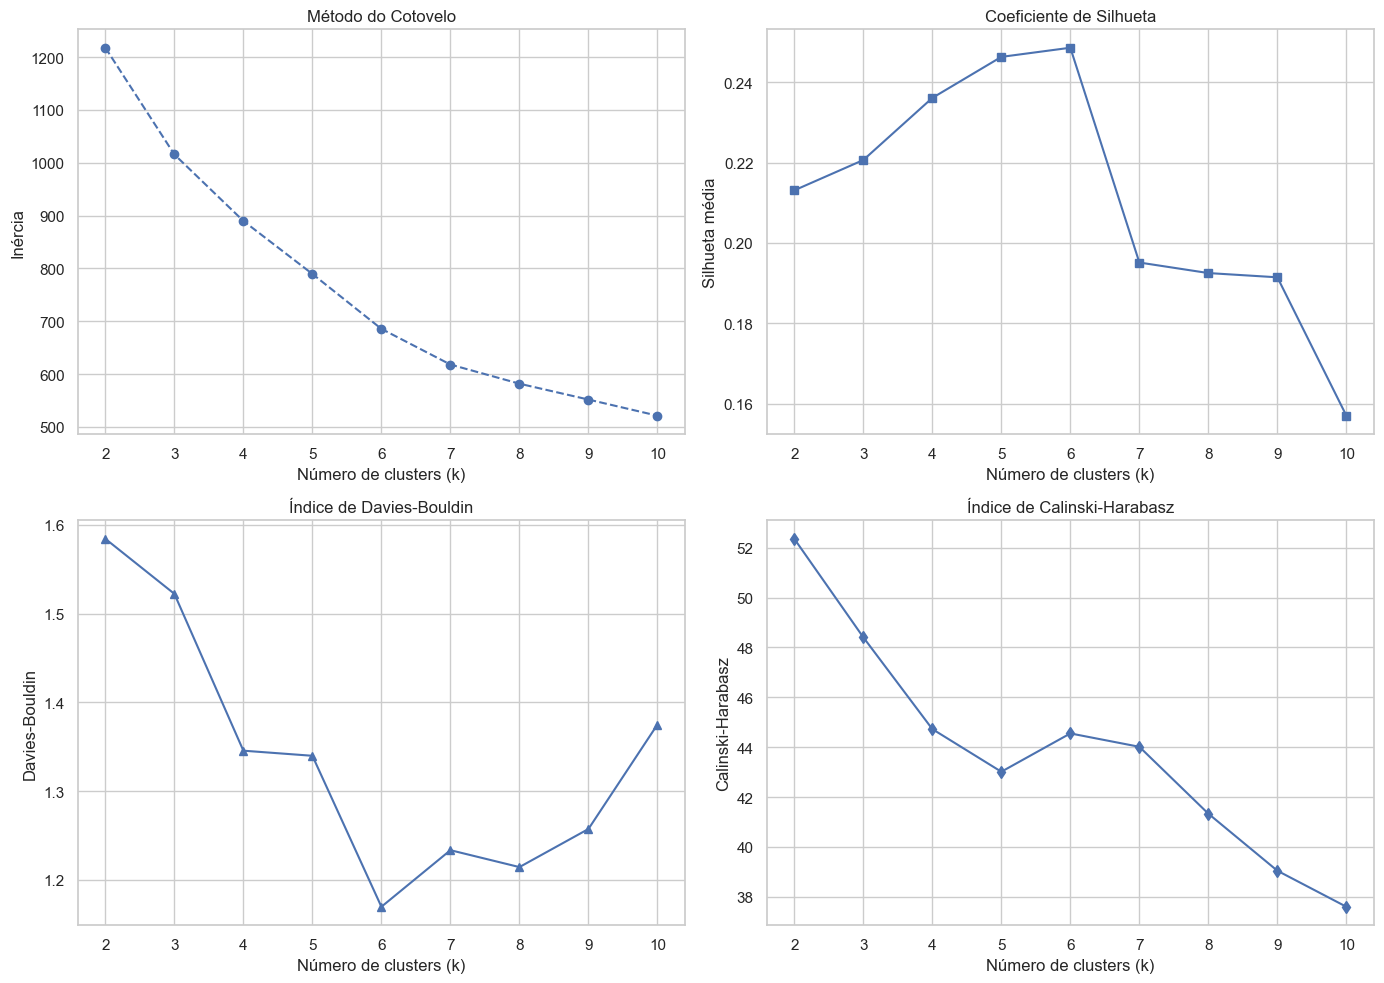

,k,inercia,silhueta,davies_bouldin,calinski_harabasz
0,2,1217.61,0.21,1.58,52.36
1,3,1015.62,0.22,1.52,48.41
2,4,889.84,0.24,1.35,44.73
3,5,789.56,0.25,1.34,43.01
4,6,685.61,0.25,1.17,44.55
5,7,618.11,0.20,1.23,44.02
6,8,581.90,0.19,1.21,41.33
7,9,551.86,0.19,1.26,39.04
8,10,521.33,0.16,1.38,37.60


In [100]:
matriz_kmeans = df_modelo_escalado[colunas_modelagem]

valores_k = list(range(2, 11))
inercia = []
silhueta = []
davies_bouldin = []
calinski_harabasz = []

for numero_clusters in valores_k:
    modelo_k = KMeans(
        n_clusters=numero_clusters,
        random_state=SEMENTE_ALEATORIA,
        n_init=20,
    )
    rotulos_k = modelo_k.fit_predict(matriz_kmeans)
    inercia.append(modelo_k.inertia_)
    silhueta.append(silhouette_score(matriz_kmeans, rotulos_k))
    davies_bouldin.append(davies_bouldin_score(matriz_kmeans, rotulos_k))
    calinski_harabasz.append(calinski_harabasz_score(matriz_kmeans, rotulos_k))

resultados_k = pd.DataFrame(
    {
        "k": valores_k,
        "inercia": inercia,
        "silhueta": silhueta,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
    }
)

figura, eixos = plt.subplots(2, 2, figsize=(14, 10))

eixos[0, 0].plot(resultados_k["k"], resultados_k["inercia"], marker="o", linestyle="--")
eixos[0, 0].set_title("Método do Cotovelo")
eixos[0, 0].set_xlabel("Número de clusters (k)")
eixos[0, 0].set_ylabel("Inércia")

eixos[0, 1].plot(resultados_k["k"], resultados_k["silhueta"], marker="s")
eixos[0, 1].set_title("Coeficiente de Silhueta")
eixos[0, 1].set_xlabel("Número de clusters (k)")
eixos[0, 1].set_ylabel("Silhueta média")

eixos[1, 0].plot(resultados_k["k"], resultados_k["davies_bouldin"], marker="^")
eixos[1, 0].set_title("Índice de Davies-Bouldin")
eixos[1, 0].set_xlabel("Número de clusters (k)")
eixos[1, 0].set_ylabel("Davies-Bouldin")

eixos[1, 1].plot(resultados_k["k"], resultados_k["calinski_harabasz"], marker="d")
eixos[1, 1].set_title("Índice de Calinski-Harabasz")
eixos[1, 1].set_xlabel("Número de clusters (k)")
eixos[1, 1].set_ylabel("Calinski-Harabasz")

plt.tight_layout()
plt.show()

resultados_k

## 7.2 Modelo final, validade interna e perfil dos clusters

Com base nas métricas anteriores, ajusta-se o modelo final de K-Means e descrevem-se os perfis médios das unidades em cada cluster. Como a representação das unidades ficou mais rica, a leitura substantiva dos agrupamentos passa a considerar simultaneamente nutrição, IMC, composição etária, sexo, raça declarada e origem dos registros no sistema.

Além do perfil médio, esta seção passa a documentar a validade interna da solução escolhida por meio de índices complementares, da distribuição de silhueta das unidades e da distância entre centróides. Isso permite sustentar de forma mais rigorosa tanto a escolha de `k=6` quanto a identificação dos clusters mais próximos entre si.

O valor final de k foi fixado em 6 após considerar silhueta, Davies-Bouldin, Calinski-Harabasz e a interpretabilidade substantiva dos grupos.

Resumo do perfil médio por cluster:


,quantidade_unidades,media_escore_saudavel,media_imc,media_idade,proporcao_mulheres,proporcao_crianca,proporcao_idoso,proporcao_branca,proporcao_parda,proporcao_preta,proporcao_auxilio_brasil,proporcao_raca_valida,media_total_atendimentos
cluster,,,,,,,,,,,,,
0,44,5.48,22.84,18.80,0.66,0.50,0.06,0.33,0.59,0.08,0.25,0.48,450.45
1,9,5.40,27.65,51.98,0.91,0.03,0.39,0.50,0.44,0.05,0.07,0.38,100.78
2,23,5.35,23.20,20.76,0.74,0.41,0.05,0.24,0.68,0.08,0.58,0.66,576.30
3,13,4.05,29.60,48.96,0.92,0.00,0.23,0.26,0.65,0.09,0.11,0.46,51.38
4,2,7.07,24.50,31.66,0.01,0.00,0.02,0.20,0.61,0.20,0.00,0.42,176.50
5,85,5.15,25.53,32.52,0.68,0.27,0.17,0.28,0.61,0.10,0.18,0.48,957.73



Indicadores de validade interna para k=6:


,Métrica,Valor,Interpretação
0,Silhueta média,0.25,maior é melhor
1,Davies-Bouldin,1.17,menor é melhor
2,Calinski-Harabasz,44.55,maior é melhor


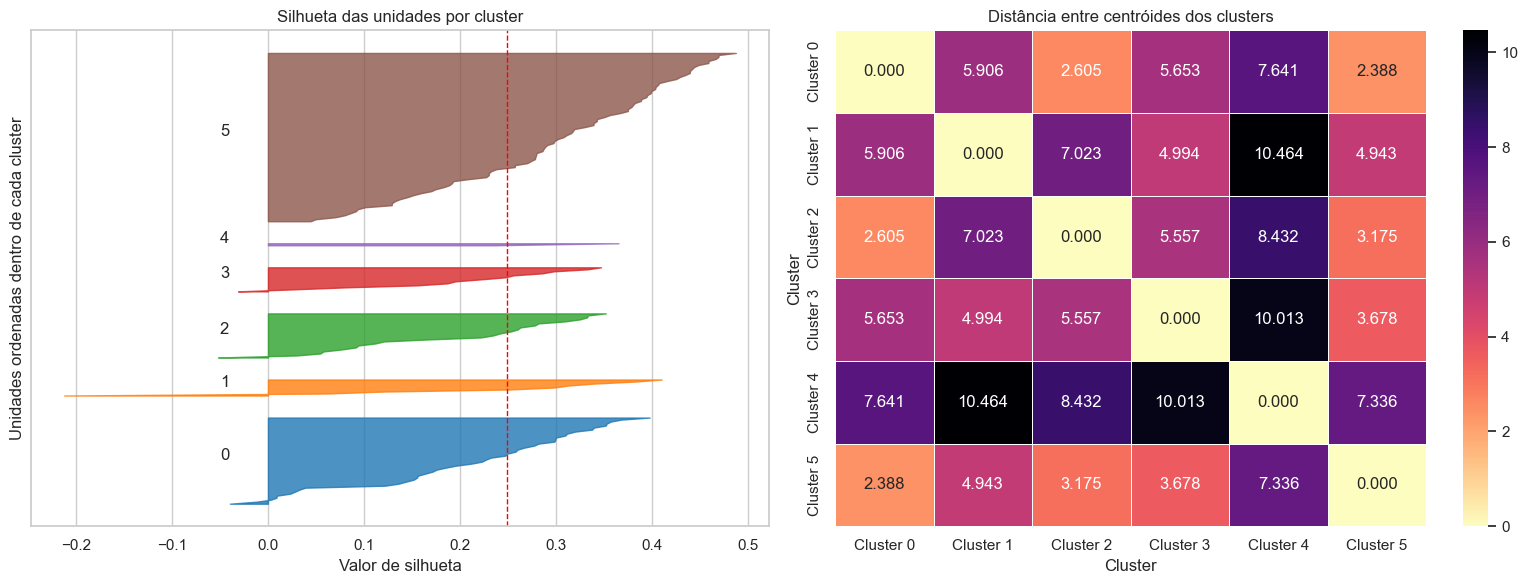

In [101]:
k_clusters = 6
modelo_kmeans = KMeans(
    n_clusters=k_clusters,
    random_state=SEMENTE_ALEATORIA,
    n_init=20,
)
rotulos_clusters = modelo_kmeans.fit_predict(matriz_kmeans)

df_unidades_saude["cluster"] = rotulos_clusters
df_modelo_escalado["cluster"] = rotulos_clusters

clusters_ordenados = sorted(df_unidades_saude["cluster"].unique())
cores_clusters = sns.color_palette("tab10", n_colors=len(clusters_ordenados)).as_hex()
paleta_clusters_dinamica = dict(zip(clusters_ordenados, cores_clusters))
paleta_clusters_plotly = {
    f"Cluster {cluster}": cor for cluster, cor in paleta_clusters_dinamica.items()
}

perfil_clusters = (
    df_unidades_saude.groupby("cluster")
    .agg(
        quantidade_unidades=("CO_CNES", "count"),
        media_escore_saudavel=("media_escore_saudavel", "mean"),
        media_imc=("media_imc", "mean"),
        media_idade=("media_idade", "mean"),
        proporcao_mulheres=("proporcao_mulheres", "mean"),
        proporcao_crianca=("proporcao_crianca", "mean"),
        proporcao_idoso=("proporcao_idoso", "mean"),
        proporcao_branca=("proporcao_branca", "mean"),
        proporcao_parda=("proporcao_parda", "mean"),
        proporcao_preta=("proporcao_preta", "mean"),
        proporcao_auxilio_brasil=("proporcao_auxilio_brasil", "mean"),
        proporcao_raca_valida=("proporcao_raca_valida", "mean"),
        media_total_atendimentos=("total_atendimentos", "mean"),
    )
    .round(2)
    .sort_index()
)

validacao_k6 = pd.DataFrame(
    {
        "Métrica": [
            "Silhueta média",
            "Davies-Bouldin",
            "Calinski-Harabasz",
        ],
        "Valor": [
            silhouette_score(matriz_kmeans, rotulos_clusters),
            davies_bouldin_score(matriz_kmeans, rotulos_clusters),
            calinski_harabasz_score(matriz_kmeans, rotulos_clusters),
        ],
        "Interpretação": [
            "maior é melhor",
            "menor é melhor",
            "maior é melhor",
        ],
    }
).round(4)

silhuetas_amostrais = silhouette_samples(matriz_kmeans, rotulos_clusters)
df_silhueta = pd.DataFrame(
    {
        "cluster": rotulos_clusters,
        "silhueta": silhuetas_amostrais,
    },
    index=df_unidades_saude.index,
)

distancia_centroides = pd.DataFrame(
    pairwise_distances(modelo_kmeans.cluster_centers_),
    index=[f"Cluster {cluster}" for cluster in clusters_ordenados],
    columns=[f"Cluster {cluster}" for cluster in clusters_ordenados],
).round(3)

print(
    f"O valor final de k foi fixado em {k_clusters} após considerar silhueta, Davies-Bouldin, Calinski-Harabasz e a interpretabilidade substantiva dos grupos."
)
print("\nResumo do perfil médio por cluster:")
display(perfil_clusters)
print("\nIndicadores de validade interna para k=6:")
display(validacao_k6)

figura, eixos = plt.subplots(1, 2, figsize=(16, 6))

ordem_plot = sorted(df_silhueta["cluster"].unique())
y_limite_inferior = 10
for cluster in ordem_plot:
    valores_cluster = np.sort(df_silhueta.loc[df_silhueta["cluster"] == cluster, "silhueta"].to_numpy())
    tamanho_cluster = len(valores_cluster)
    y_limite_superior = y_limite_inferior + tamanho_cluster
    eixos[0].fill_betweenx(
        np.arange(y_limite_inferior, y_limite_superior),
        0,
        valores_cluster,
        alpha=0.8,
        color=paleta_clusters_dinamica[cluster],
    )
    eixos[0].text(-0.05, y_limite_inferior + 0.5 * tamanho_cluster, str(cluster))
    y_limite_inferior = y_limite_superior + 10

eixos[0].axvline(df_silhueta["silhueta"].mean(), color="red", linestyle="--", linewidth=1)
eixos[0].set_title("Silhueta das unidades por cluster")
eixos[0].set_xlabel("Valor de silhueta")
eixos[0].set_ylabel("Unidades ordenadas dentro de cada cluster")
eixos[0].set_yticks([])

eixos[1] = sns.heatmap(
    distancia_centroides,
    annot=True,
    cmap="magma_r",
    fmt=".3f",
    linewidths=0.5,
    ax=eixos[1],
)
eixos[1].set_title("Distância entre centróides dos clusters")
eixos[1].set_xlabel("Cluster")
eixos[1].set_ylabel("Cluster")

plt.tight_layout()
plt.show()

### Visualização com UMAP

A projeção UMAP foi configurada com `n_neighbors=15` e `min_dist=0.2` porque esse ajuste ofereceu o melhor equilíbrio entre preservação da estrutura global e separação visual dos grupos para as 176 unidades analisadas. Em termos práticos, ele evita tanto uma fragmentação excessivamente local quanto uma compressão artificial dos clusters, produzindo uma visualização mais estável e interpretável.

/Users/lucasreis/Documents/sisvan-clustering-analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


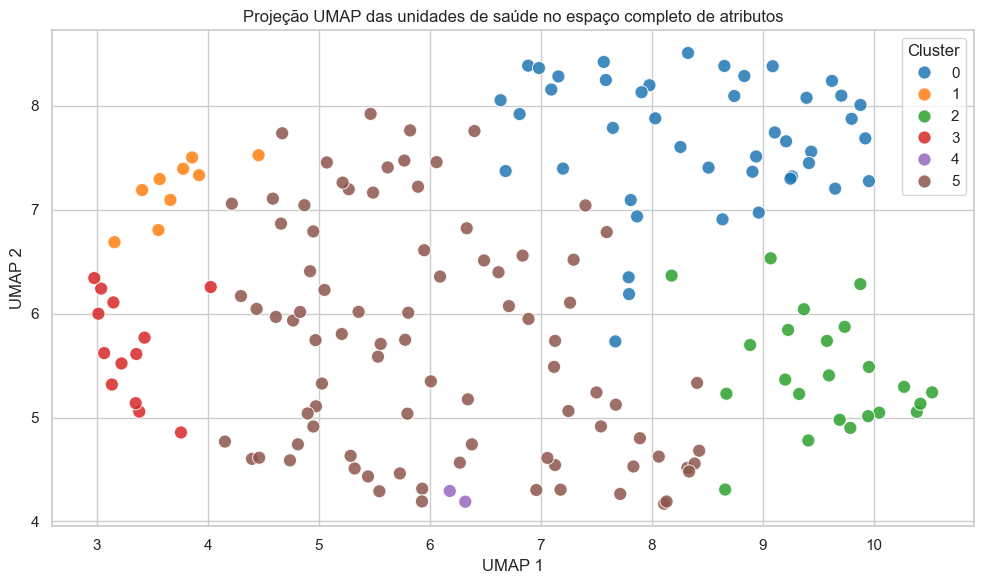

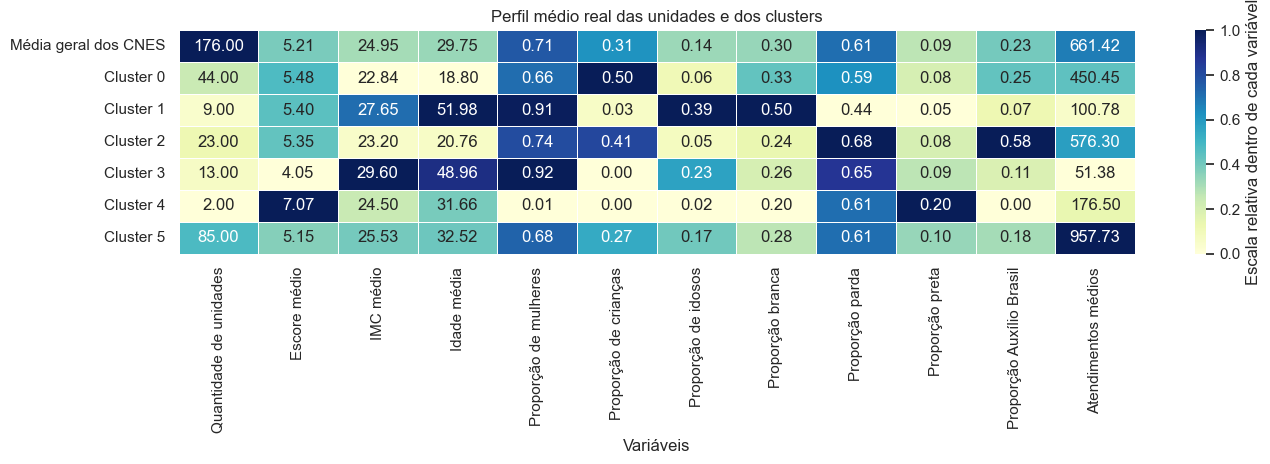

In [102]:
import umap.umap_ as umap

projecao_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.2,
    metric="euclidean",
    random_state=SEMENTE_ALEATORIA,
)

coordenadas_umap = projecao_umap.fit_transform(df_modelo_escalado[colunas_modelagem])
df_umap_clusters = df_modelo_escalado.copy()
df_umap_clusters["umap_1"] = coordenadas_umap[:, 0]
df_umap_clusters["umap_2"] = coordenadas_umap[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_umap_clusters,
    x="umap_1",
    y="umap_2",
    hue="cluster",
    palette=paleta_clusters_dinamica,
    s=90,
    alpha=0.85,
)
plt.title("Projeção UMAP das unidades de saúde no espaço completo de atributos")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

colunas_perfil_base = [
    "media_escore_saudavel",
    "media_imc",
    "media_idade",
    "proporcao_mulheres",
    "proporcao_crianca",
    "proporcao_idoso",
    "proporcao_branca",
    "proporcao_parda",
    "proporcao_preta",
    "proporcao_auxilio_brasil",
    "total_atendimentos",
]

base_perfil_clusters = (
    df_unidades_saude.groupby("cluster")
    .agg(
        quantidade_unidades=("CO_CNES", "count"),
        media_escore_saudavel=("media_escore_saudavel", "mean"),
        media_imc=("media_imc", "mean"),
        media_idade=("media_idade", "mean"),
        proporcao_mulheres=("proporcao_mulheres", "mean"),
        proporcao_crianca=("proporcao_crianca", "mean"),
        proporcao_idoso=("proporcao_idoso", "mean"),
        proporcao_branca=("proporcao_branca", "mean"),
        proporcao_parda=("proporcao_parda", "mean"),
        proporcao_preta=("proporcao_preta", "mean"),
        proporcao_auxilio_brasil=("proporcao_auxilio_brasil", "mean"),
        total_atendimentos=("total_atendimentos", "mean"),
    )
    .round(2)
    .sort_index()
)

linha_media_cnes = pd.DataFrame(
    [{
        "quantidade_unidades": len(df_unidades_saude),
        **df_unidades_saude[colunas_perfil_base].mean().round(2).to_dict(),
    }],
    index=["Média geral dos CNES"],
)
perfil_real_clusters = pd.concat(
    [
        linha_media_cnes,
        base_perfil_clusters.rename(index=lambda cluster: f"Cluster {cluster}"),
    ]
)

perfil_real_clusters = perfil_real_clusters.rename(
    columns={
        "quantidade_unidades": "Quantidade de unidades",
        "media_escore_saudavel": "Escore médio",
        "media_imc": "IMC médio",
        "media_idade": "Idade média",
        "proporcao_mulheres": "Proporção de mulheres",
        "proporcao_crianca": "Proporção de crianças",
        "proporcao_idoso": "Proporção de idosos",
        "proporcao_branca": "Proporção branca",
        "proporcao_parda": "Proporção parda",
        "proporcao_preta": "Proporção preta",
        "proporcao_auxilio_brasil": "Proporção Auxílio Brasil",
        "total_atendimentos": "Atendimentos médios",
    }
).astype(float)

ordem_colunas_perfil = [
    "Quantidade de unidades",
    "Escore médio",
    "IMC médio",
    "Idade média",
    "Proporção de mulheres",
    "Proporção de crianças",
    "Proporção de idosos",
    "Proporção branca",
    "Proporção parda",
    "Proporção preta",
    "Proporção Auxílio Brasil",
    "Atendimentos médios",
]
perfil_real_clusters = perfil_real_clusters[ordem_colunas_perfil]

perfil_real_clusters_normalizado = perfil_real_clusters.apply(
    lambda coluna: (coluna - coluna.min()) / (coluna.max() - coluna.min())
    if coluna.max() > coluna.min()
    else pd.Series(0.5, index=coluna.index),
    axis=0,
)

plt.figure(figsize=(14, 4.8))
sns.heatmap(
    perfil_real_clusters_normalizado,
    annot=perfil_real_clusters,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Escala relativa dentro de cada variável"},
)
plt.title("Perfil médio real das unidades e dos clusters")
plt.xlabel("Variáveis")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Análise do perfil médio de atendimento por cluster de CNES

A leitura conjunta do heatmap mostra que os clusters não diferem apenas em volume de atendimentos, mas também no perfil demográfico, nutricional e social da população acompanhada em cada grupo de unidades.

- **(Atenção infantojuvenil)** **Cluster 0**: reúne 44 unidades com perfil mais jovem, maior proporção de crianças (0,50) e baixa presença de idosos (0,06). O escore médio saudável é relativamente alto (5,48), o IMC médio é baixo (22,84) e a participação do Auxílio Brasil (0,25) fica ligeiramente acima da média geral. Em conjunto, esse cluster sugere unidades com atendimento fortemente orientado à infância e à população jovem.

- **(Cuidado feminino longevo)** **Cluster 1**: é um grupo pequeno, com 9 unidades, mas bastante marcado pelo envelhecimento do público atendido. Apresenta a maior idade média (51,98), alta proporção de idosos (0,39), altíssima proporção de mulheres (0,91) e maior proporção branca (0,50). Ao mesmo tempo, tem baixa presença de crianças (0,03) e baixo peso do Auxílio Brasil (0,07), sugerindo unidades mais voltadas ao cuidado de adultos e idosos, com forte concentração feminina.

- **(Infância em território vulnerável)** **Cluster 2**: agrega 23 unidades com perfil intermediário, mas ainda relativamente jovem. A idade média é baixa (20,76), a proporção de crianças é alta (0,41) e a proporção de idosos é baixa (0,05). Destaca-se também pela maior participação do Auxílio Brasil (0,58), além de escore saudável acima da média geral (5,35). Esse padrão sugere unidades inseridas em territórios socialmente mais vulneráveis, mas com forte presença de crianças e adolescentes.

- **(Adulto-feminino com excesso de peso)** **Cluster 3**: reúne 13 unidades com o pior perfil nutricional médio entre os clusters mais populosos: escore saudável de 4,05 e maior IMC médio (29,60). Também apresenta idade média elevada (48,96), alta proporção de mulheres (0,92) e presença importante de idosos (0,23), mas quase nenhuma criança (0,00). Esse cluster parece representar unidades com público predominantemente adulto e idoso, mais feminino e com maior carga de excesso de peso.

- **(Perfil singular masculino saudável)** **Cluster 4**: tem apenas 2 unidades, o que exige bastante cautela interpretativa. Mesmo assim, ele chama atenção pelo maior escore saudável (7,07), proporção feminina extremamente baixa (0,01), ausência de crianças e idosos quase inexistentes (0,02), além de maior proporção preta (0,20). Trata-se de um perfil muito específico e pouco frequente, mais útil como sinal de singularidade do que como padrão consolidado da rede.

- **(Generalista de alto volume)** **Cluster 5**: é o maior agrupamento, com 85 unidades, e parece representar o perfil mais volumoso e estrutural da rede. Tem a maior média de atendimentos (957,73), idade média mais alta que a média geral (32,52), proporção moderada de idosos (0,17), baixa proporção de crianças (0,27) e IMC médio elevado (25,53). O escore saudável fica próximo da média geral (5,15), o que sugere unidades de perfil mais generalista, com grande volume assistencial e composição etária mais adulta.

De forma sintética, os resultados indicam uma rede heterogênea, com pelo menos quatro padrões substantivos: **Atenção infantojuvenil** (Cluster 0), **Cuidado feminino longevo** (Cluster 1), **Infância em território vulnerável** (Cluster 2), **Adulto-feminino com excesso de peso** (Cluster 3) e **Generalista de alto volume** (Cluster 5). O **Perfil singular masculino saudável** (Cluster 4) deve ser interpretado como um agrupamento excepcional, e não como tipo dominante da rede municipal.

## 7.3 Distribuição geográfica das unidades de saúde

Além da separação observada no espaço padronizado das variáveis, é útil examinar como as unidades se distribuem territorialmente no Recife. Os mapas a seguir têm duas funções complementares: primeiro, mostrar a cobertura espacial das unidades incluídas na análise; segundo, verificar se os clusters identificados apresentam algum padrão geográfico visível no município.

Os mapas interativos permitem examinar com mais detalhe a localização das unidades, seus bairros e sua distribuição espacial por cluster. Essa visualização aprofunda a leitura territorial dos resultados sem alterar o fato de que os clusters foram definidos a partir de variáveis sintéticas padronizadas, e não por proximidade geográfica.

In [103]:
CAMINHO_COORDENADAS_RECIFE = Path("data/cnes_coordenadas_recife.csv")

if CAMINHO_COORDENADAS_RECIFE.exists():
    df_coordenadas_recife = pd.read_csv(CAMINHO_COORDENADAS_RECIFE)
else:
    caminho_dataset_coordenadas = Path(
        kagglehub.dataset_download(
            "diacbernardortura/estabelecimentos-do-cnes-coordenadas-geogrficas"
        )
    )
    caminho_csv_coordenadas = caminho_dataset_coordenadas / "cnes_coord.csv"

    df_coordenadas_recife = pd.read_csv(
        caminho_csv_coordenadas,
        usecols=[
            "co_ibge",
            "co_cnes",
            "endereco_completo",
            "no_logradouro",
            "nu_endereco",
            "no_bairro",
            "co_cep",
            "municipio",
            "uf",
            "lat",
            "long",
        ],
    )
    df_coordenadas_recife = df_coordenadas_recife.loc[
        (df_coordenadas_recife["municipio"].astype("string").str.upper() == "RECIFE")
        & (df_coordenadas_recife["uf"].astype("string").str.upper() == "PE")
    ].copy()
    df_coordenadas_recife.to_csv(CAMINHO_COORDENADAS_RECIFE, index=False)

df_coordenadas_recife["co_cnes"] = pd.to_numeric(
    df_coordenadas_recife["co_cnes"], errors="coerce"
).astype("Int64")
df_coordenadas_recife["lat"] = pd.to_numeric(df_coordenadas_recife["lat"], errors="coerce")
df_coordenadas_recife["long"] = pd.to_numeric(df_coordenadas_recife["long"], errors="coerce")

df_mapa_unidades = df_unidades_saude.copy()
df_mapa_unidades["CO_CNES"] = pd.to_numeric(
    df_mapa_unidades["CO_CNES"], errors="coerce"
).astype("Int64")

df_mapa_unidades = df_mapa_unidades.merge(
    df_coordenadas_recife.drop_duplicates(subset=["co_cnes"]),
    left_on="CO_CNES",
    right_on="co_cnes",
    how="left",
)
df_mapa_unidades = df_mapa_unidades.dropna(subset=["lat", "long"]).copy()

print(f"Unidades com coordenadas disponíveis: {len(df_mapa_unidades)}")
print(f"Unidades sem coordenadas: {len(df_unidades_saude) - len(df_mapa_unidades)}")

Unidades com coordenadas disponíveis: 176
Unidades sem coordenadas: 0


In [104]:
nomes_clusters = {
    0: "Atenção infantojuvenil",
    1: "Cuidado feminino longevo",
    2: "Infância em território vulnerável",
    3: "Adulto-feminino com excesso de peso",
    4: "Perfil singular masculino saudável",
    5: "Generalista de alto volume",
}

df_mapa_unidades["cluster_cat"] = df_mapa_unidades["cluster"].map(
    lambda cluster: nomes_clusters.get(cluster, "Sem rótulo")
)
df_mapa_unidades["cnes_hover"] = "CNES " + df_mapa_unidades["CO_CNES"].astype(str)

centro_recife = {"lat": float(df_mapa_unidades["lat"].mean()), "lon": float(df_mapa_unidades["long"].mean())}

clusters_mapa = sorted(df_mapa_unidades["cluster"].unique())
cores_mapa = [
    "#D32F2F",  # vermelho
    "#F57C00",  # laranja
    "#7B1FA2",  # roxo
    "#C2185B",  # magenta
    "#5D4037",  # marrom
    "#212121",  # grafite
]
paleta_clusters_mapa = {
    nomes_clusters.get(cluster, "Sem rótulo"): cores_mapa[indice % len(cores_mapa)]
    for indice, cluster in enumerate(clusters_mapa)
}

fig_mapa_clusters = px.scatter_map(
    df_mapa_unidades,
    lat="lat",
    lon="long",
    color="cluster_cat",
    hover_name="cnes_hover",
    hover_data={
        "cluster_cat": True,
        "lat": ":.5f",
        "long": ":.5f",
        "no_bairro": True,
        "endereco_completo": True,
    },
    color_discrete_map=paleta_clusters_mapa,
    zoom=11,
    center=centro_recife,
    map_style="open-street-map",
    title="Distribuição espacial das unidades de saúde por cluster",
)
fig_mapa_clusters.update_traces(marker={"size": 12, "opacity": 0.90})
fig_mapa_clusters.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=550,
    legend_title_text="Perfil do cluster",
)
fig_mapa_clusters.show()

Distribuição das unidades por cluster:
cluster
0    44
1     9
2    23
3    13
4     2
5    85
Name: count, dtype: int64

Clusters excluídos da inferência por tamanho insuficiente (< 5 unidades): 4

Nota metodológica:
A comparação de media_escore_saudavel entre clusters mede principalmente a consistência interna da partição, pois essa variável também foi usada na formação dos grupos. As evidências inferenciais mais fortes, portanto, estão nas variáveis externas ao processo de clusterização, como media_idade e total_atendimentos.

Escore médio saudável por cluster — validade interna (comparação circular)


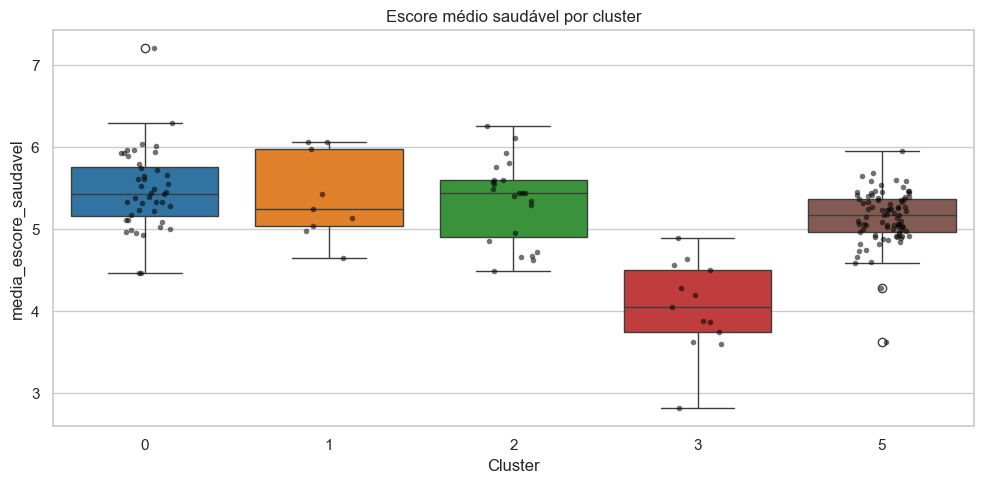

Teste de normalidade de Shapiro-Wilk por cluster elegível:
Atenção infantojuvenil (Cluster 0): n=44, W=0.9469, p-valor=0.0422
Cuidado feminino longevo (Cluster 1): n=9, W=0.8976, p-valor=0.2382
Infância em território vulnerável (Cluster 2): n=23, W=0.9441, p-valor=0.2204
Adulto-feminino com excesso de peso (Cluster 3): n=13, W=0.9618, p-valor=0.7807
Generalista de alto volume (Cluster 5): n=85, W=0.9272, p-valor=0.0001

Resultados globais dos testes:
Levene: estatística=2.8126, p-valor=0.0271
ANOVA (referência): estatística F=30.0438, p-valor=7.0153e-19
Kruskal-Wallis: estatística H=47.6791, p-valor=1.1010e-09
Eta-quadrado da ANOVA: 0.4156
Epsilon-quadrado de Kruskal-Wallis: 0.2585


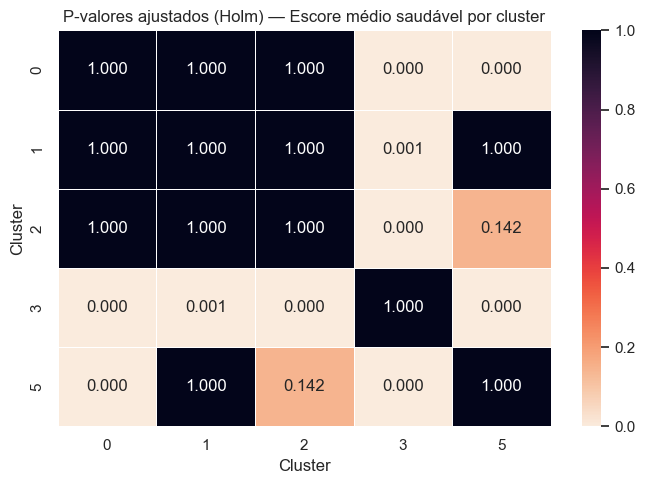


Idade média por cluster — comparação externa ao algoritmo


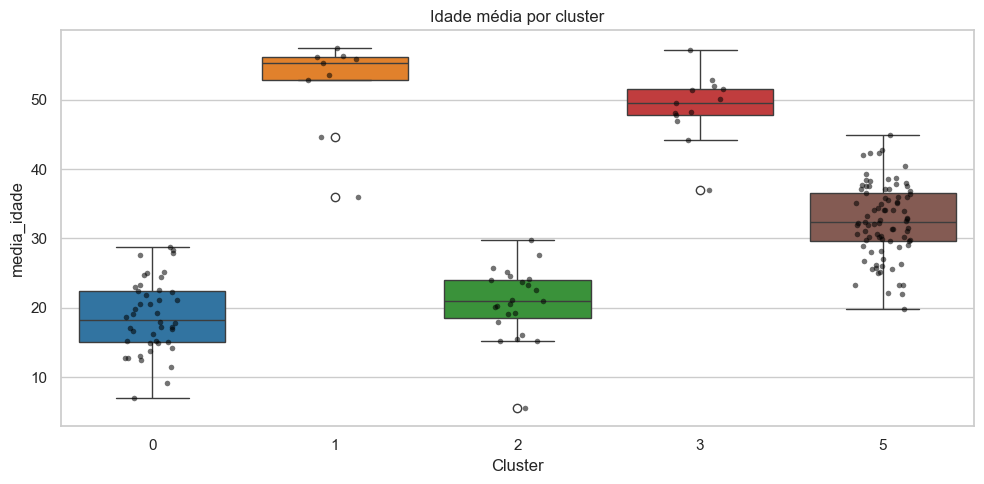

Teste de normalidade de Shapiro-Wilk por cluster elegível:
Atenção infantojuvenil (Cluster 0): n=44, W=0.9838, p-valor=0.7845
Cuidado feminino longevo (Cluster 1): n=9, W=0.7361, p-valor=0.0037
Infância em território vulnerável (Cluster 2): n=23, W=0.9385, p-valor=0.1668
Adulto-feminino com excesso de peso (Cluster 3): n=13, W=0.9206, p-valor=0.2558
Generalista de alto volume (Cluster 5): n=85, W=0.9909, p-valor=0.8247

Resultados globais dos testes:
Levene: estatística=0.3378, p-valor=0.8522
ANOVA (referência): estatística F=149.4835, p-valor=2.0877e-54
Kruskal-Wallis: estatística H=129.1413, p-valor=5.9434e-27
Eta-quadrado da ANOVA: 0.7796
Epsilon-quadrado de Kruskal-Wallis: 0.7405


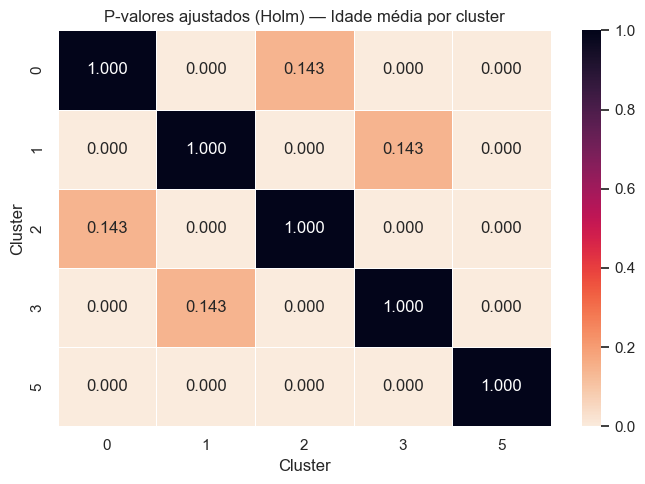


Total de atendimentos por cluster — comparação externa ao algoritmo


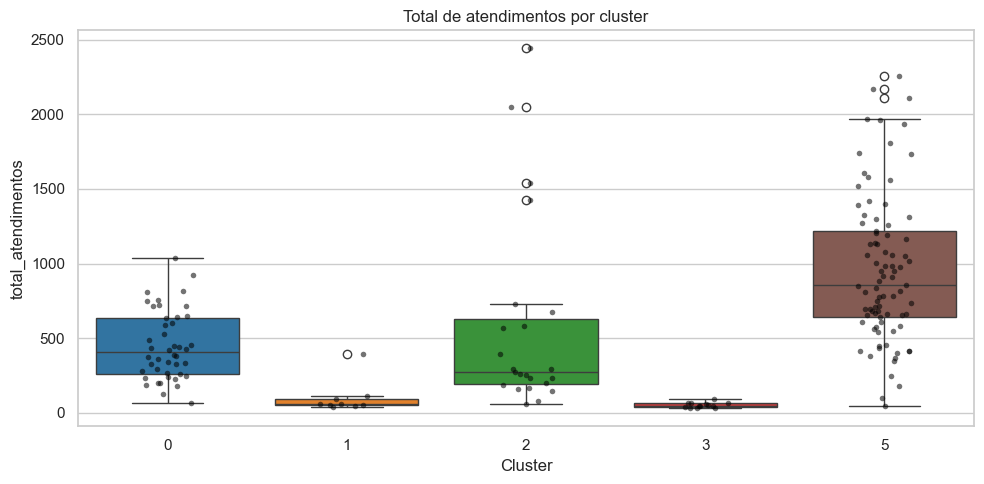

Teste de normalidade de Shapiro-Wilk por cluster elegível:
Atenção infantojuvenil (Cluster 0): n=44, W=0.9524, p-valor=0.0673
Cuidado feminino longevo (Cluster 1): n=9, W=0.5655, p-valor=0.0000
Infância em território vulnerável (Cluster 2): n=23, W=0.7150, p-valor=0.0000
Adulto-feminino com excesso de peso (Cluster 3): n=13, W=0.9163, p-valor=0.2234
Generalista de alto volume (Cluster 5): n=85, W=0.9578, p-valor=0.0072

Resultados globais dos testes:
Levene: estatística=7.1208, p-valor=0.0000
ANOVA (referência): estatística F=22.5942, p-valor=5.7907e-15
Kruskal-Wallis: estatística H=85.9738, p-valor=9.4265e-18
Eta-quadrado da ANOVA: 0.3484
Epsilon-quadrado de Kruskal-Wallis: 0.4851


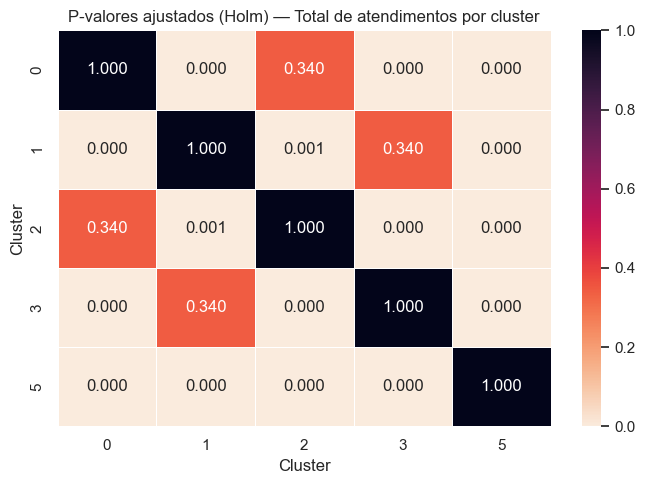


Resumo inferencial consolidado:


,variavel,tipo,p_shapiro_min,p_levene,estatistica_kw,p_kw,epsilon_quadrado
0,media_escore_saudavel,validade interna (comparação circular),0.00,0.03,47.68,0.00,0.26
1,media_idade,comparação externa ao algoritmo,0.00,0.85,129.14,0.00,0.74
2,total_atendimentos,comparação externa ao algoritmo,0.00,0.00,85.97,0.00,0.49



Síntese interpretativa: a solução com k=6 é sustentada principalmente pelos indicadores de validade interna e pela distância entre centróides. As diferenças em media_idade e total_atendimentos oferecem evidência externa mais robusta de que os grupos capturam perfis assistenciais distintos.


In [105]:
if (
    "cluster" not in df_unidades_saude.columns
    or df_unidades_saude["cluster"].nunique() != k_clusters
):
    modelo_kmeans = KMeans(
        n_clusters=k_clusters,
        random_state=SEMENTE_ALEATORIA,
        n_init=20,
    )
    rotulos_clusters = modelo_kmeans.fit_predict(matriz_kmeans)
    df_unidades_saude["cluster"] = rotulos_clusters
    df_modelo_escalado["cluster"] = rotulos_clusters

nomes_clusters = {
    0: "Atenção infantojuvenil",
    1: "Cuidado feminino longevo",
    2: "Infância em território vulnerável",
    3: "Adulto-feminino com excesso de peso",
    4: "Perfil singular masculino saudável",
    5: "Generalista de alto volume",
}

def epsilon_quadrado_kruskal(estatistica_h, numero_grupos, numero_observacoes):
    if numero_observacoes <= numero_grupos:
        return np.nan
    return max(0, (estatistica_h - numero_grupos + 1) / (numero_observacoes - numero_grupos))

def dunn_holm(df, variavel, coluna_grupo="cluster"):
    grupos = sorted(df[coluna_grupo].unique())
    comparacoes = []
    valores_p = []
    for grupo_a, grupo_b in combinations(grupos, 2):
        serie_a = df.loc[df[coluna_grupo] == grupo_a, variavel]
        serie_b = df.loc[df[coluna_grupo] == grupo_b, variavel]
        _, valor_p = stats.mannwhitneyu(serie_a, serie_b, alternative="two-sided")
        comparacoes.append((grupo_a, grupo_b))
        valores_p.append(valor_p)

    ordem = np.argsort(valores_p)
    p_ajustados = np.empty(len(valores_p), dtype=float)
    maximo_acumulado = 0.0
    total_testes = len(valores_p)

    for posicao, indice in enumerate(ordem):
        fator = total_testes - posicao
        valor_ajustado = min(1.0, valores_p[indice] * fator)
        maximo_acumulado = max(maximo_acumulado, valor_ajustado)
        p_ajustados[indice] = maximo_acumulado

    matriz = pd.DataFrame(
        np.ones((len(grupos), len(grupos))),
        index=grupos,
        columns=grupos,
        dtype=float,
    )
    for (grupo_a, grupo_b), valor_ajustado in zip(comparacoes, p_ajustados):
        matriz.loc[grupo_a, grupo_b] = valor_ajustado
        matriz.loc[grupo_b, grupo_a] = valor_ajustado
    return matriz

contagem_clusters = df_unidades_saude["cluster"].value_counts().sort_index()
clusters_elegiveis = contagem_clusters[contagem_clusters >= 5].index.tolist()
clusters_excluidos = contagem_clusters[contagem_clusters < 5].index.tolist()

df_inferencia = df_unidades_saude.loc[
    df_unidades_saude["cluster"].isin(clusters_elegiveis)
].copy()
df_inferencia["nome_cluster"] = df_inferencia["cluster"].map(
    lambda cluster: nomes_clusters.get(cluster, f"Cluster {cluster}")
)

print("Distribuição das unidades por cluster:")
print(contagem_clusters)

if clusters_excluidos:
    print(
        "\nClusters excluídos da inferência por tamanho insuficiente (< 5 unidades): "
        + ", ".join(map(str, clusters_excluidos))
    )

texto_cautela = (
    "A comparação de media_escore_saudavel entre clusters mede principalmente a consistência interna da partição, "
    "pois essa variável também foi usada na formação dos grupos. As evidências inferenciais mais fortes, portanto, "
    "estão nas variáveis externas ao processo de clusterização, como media_idade e total_atendimentos."
)
print("\nNota metodológica:")
print(texto_cautela)

variaveis_analise = {
    "media_escore_saudavel": {
        "titulo": "Escore médio saudável por cluster",
        "descricao": "validade interna (comparação circular)",
    },
    "media_idade": {
        "titulo": "Idade média por cluster",
        "descricao": "comparação externa ao algoritmo",
    },
    "total_atendimentos": {
        "titulo": "Total de atendimentos por cluster",
        "descricao": "comparação externa ao algoritmo",
    },
}

resumos_testes = []
matrizes_pos_hoc = {}

for variavel_resposta, metadados in variaveis_analise.items():
    grupo_inferencia = df_inferencia.groupby("cluster")[variavel_resposta]
    series_grupos = [serie for _, serie in grupo_inferencia]

    print(f"\n{'=' * 80}")
    print(f"{metadados['titulo']} — {metadados['descricao']}")
    print(f"{'=' * 80}")

    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df_inferencia,
        x="cluster",
        y=variavel_resposta,
        hue="cluster",
        palette=paleta_clusters_dinamica,
        dodge=False,
        legend=False,
    )
    sns.stripplot(
        data=df_inferencia,
        x="cluster",
        y=variavel_resposta,
        color="black",
        size=4,
        alpha=0.55,
        jitter=0.15,
    )
    plt.title(metadados["titulo"])
    plt.xlabel("Cluster")
    plt.ylabel(variavel_resposta)
    plt.tight_layout()
    plt.show()

    print("Teste de normalidade de Shapiro-Wilk por cluster elegível:")
    p_shapiro_clusters = []
    for cluster, serie in grupo_inferencia:
        estatistica_shapiro, p_shapiro = stats.shapiro(serie)
        p_shapiro_clusters.append(p_shapiro)
        print(
            f"{nomes_clusters.get(cluster, f'Cluster {cluster}')} (Cluster {cluster}): "
            f"n={len(serie)}, W={estatistica_shapiro:.4f}, p-valor={p_shapiro:.4f}"
        )

    estatistica_levene, p_levene = stats.levene(*series_grupos)
    estatistica_anova, p_anova = stats.f_oneway(*series_grupos)
    estatistica_kruskal, p_kruskal = stats.kruskal(*series_grupos)

    numero_grupos = len(series_grupos)
    numero_observacoes = len(df_inferencia)
    eta_quadrado = (
        (estatistica_anova * (numero_grupos - 1))
        / ((estatistica_anova * (numero_grupos - 1)) + (numero_observacoes - numero_grupos))
    )
    epsilon_quadrado = epsilon_quadrado_kruskal(
        estatistica_kruskal,
        numero_grupos,
        numero_observacoes,
    )

    print("\nResultados globais dos testes:")
    print(f"Levene: estatística={estatistica_levene:.4f}, p-valor={p_levene:.4f}")
    print(f"ANOVA (referência): estatística F={estatistica_anova:.4f}, p-valor={p_anova:.4e}")
    print(f"Kruskal-Wallis: estatística H={estatistica_kruskal:.4f}, p-valor={p_kruskal:.4e}")
    print(f"Eta-quadrado da ANOVA: {eta_quadrado:.4f}")
    print(f"Epsilon-quadrado de Kruskal-Wallis: {epsilon_quadrado:.4f}")

    matriz_dunn = dunn_holm(df_inferencia, variavel_resposta)
    matrizes_pos_hoc[variavel_resposta] = matriz_dunn

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matriz_dunn,
        annot=True,
        cmap="rocket_r",
        vmin=0,
        vmax=1,
        fmt=".3f",
        linewidths=0.5,
    )
    plt.title(f"P-valores ajustados (Holm) — {metadados['titulo']}")
    plt.xlabel("Cluster")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

    resumos_testes.append(
        {
            "variavel": variavel_resposta,
            "tipo": metadados["descricao"],
            "p_shapiro_min": np.min(p_shapiro_clusters),
            "p_levene": p_levene,
            "estatistica_kw": estatistica_kruskal,
            "p_kw": p_kruskal,
            "epsilon_quadrado": epsilon_quadrado,
        }
    )

resumo_inferencial = pd.DataFrame(resumos_testes).round(4)
print("\nResumo inferencial consolidado:")
display(resumo_inferencial)

print(
    "\nSíntese interpretativa: a solução com k=6 é sustentada principalmente pelos indicadores de validade interna e pela distância entre centróides. "
    "As diferenças em media_idade e total_atendimentos oferecem evidência externa mais robusta de que os grupos capturam perfis assistenciais distintos."
)

## 9. Considerações Finais

Os resultados mostram que a rede de unidades de saúde do Recife não é homogênea quando resumida por indicadores nutricionais, etários, sociodemográficos e de volume assistencial. A solução com seis clusters deve ser entendida como uma síntese analítica plausível e interpretável da heterogeneidade observada, sustentada por múltiplos indicadores de validade interna — incluindo silhueta média, Davies-Bouldin, Calinski-Harabasz, distribuição de silhuetas individuais e distância entre centróides.

Ao mesmo tempo, a análise inferencial exige uma leitura metodologicamente cuidadosa. Diferenças estatisticamente significativas em `media_escore_saudavel` entre clusters reforçam a consistência interna da partição, mas não constituem validação independente, porque essa variável também participou da própria formação dos grupos. Em outras palavras, essa evidência mostra que o algoritmo separou bem uma dimensão que ele já estava usando para separar.

A sustentação estatística mais robusta da tipologia proposta aparece nas variáveis externas ao processo de clusterização, sobretudo `media_idade` e `total_atendimentos`. Quando essas variáveis também diferenciam os grupos, ganha força a interpretação de que os clusters representam perfis assistenciais substantivamente distintos, e não apenas artefatos geométricos da otimização do K-Means.

Do ponto de vista substantivo, os clusters identificados sugerem uma rede com perfis de atendimento relativamente estáveis: unidades orientadas à infância, grupos com maior envelhecimento e feminização do cuidado, contextos de maior vulnerabilidade social e unidades generalistas de grande volume. Os agrupamentos muito pequenos devem continuar sendo tratados com cautela, como perfis excepcionais dentro da rede, e não como tipos dominantes.

Assim, o notebook passa a oferecer uma narrativa mais completa: primeiro, descreve os perfis médios das unidades; depois, mostra que a solução de agrupamento possui coerência interna; por fim, distingue com mais rigor o que pode ser interpretado como validade estatística interna e o que, de fato, funciona como evidência externa mais convincente sobre diferenças entre clusters. Esse encadeamento fortalece a análise e aproxima o trabalho de um padrão metodológico mais consistente para projetos aplicados em estatística e saúde pública.